# MATRIZ ABSOLUTA, MATRIZ NORMALIZADA Y RECALL POR CLASE
# Modelo: LinSVC
# Para tesis - Retinopatía diabética

In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# 1. Configuración general

In [80]:
# Carpeta donde se guardarán las figuras y tablas
OUTDIR = Path("resultados_matrices_tesis")
OUTDIR.mkdir(parents=True, exist_ok=True)

# Nombre del modelo
model_name = "EfficientNet-B0 Holdout Messidor"

# Nombres de clases diagnósticas
class_names = ["No RD", "Leve", "Moderado", "Severo", "PRD"]

# 2. Matriz de confusión absoluta
#    Esta matriz es la que ya tienes en tu documento

In [81]:
cm_abs = np.array([
    [10,  4,  1,  0, 0],
    [22, 27, 12,  1, 0],
    [ 1,  6, 20, 19, 0],
    [ 0,  0,  0, 62, 0],
    [ 0,  0,  0, 15, 6]
])

# Convertir a DataFrame para visualizar mejor
cm_abs_df = pd.DataFrame(
    cm_abs,
    index=[f"Real: {c}" for c in class_names],
    columns=[f"Pred: {c}" for c in class_names]
)

print("Matriz de confusión absoluta:")
display(cm_abs_df)

# Guardar matriz absoluta en CSV
cm_abs_df.to_csv(OUTDIR / f"{model_name}_matriz_absoluta.csv", encoding="utf-8-sig")

Matriz de confusión absoluta:


,Pred: No RD,Pred: Leve,Pred: Moderado,Pred: Severo,Pred: PRD
Real: No RD,10,4,1,0,0
Real: Leve,22,27,12,1,0
Real: Moderado,1,6,20,19,0
Real: Severo,0,0,0,62,0
Real: PRD,0,0,0,15,6


# 3. Matriz de confusión normalizada por fila
#    Cada fila suma 1.00, es decir, muestra proporciones por clase real

In [82]:
row_sums = cm_abs.sum(axis=1, keepdims=True)
cm_norm = cm_abs / row_sums

cm_norm_df = pd.DataFrame(
    cm_norm,
    index=[f"Real: {c}" for c in class_names],
    columns=[f"Pred: {c}" for c in class_names]
)

print("Matriz de confusión normalizada por fila:")
display(cm_norm_df.round(4))

# Guardar matriz normalizada en CSV
cm_norm_df.to_csv(OUTDIR / f"{model_name}_matriz_normalizada_por_fila.csv", encoding="utf-8-sig")

Matriz de confusión normalizada por fila:


,Pred: No RD,Pred: Leve,Pred: Moderado,Pred: Severo,Pred: PRD
Real: No RD,0.6667,0.2667,0.0667,0.0000,0.0000
Real: Leve,0.3548,0.4355,0.1935,0.0161,0.0000
Real: Moderado,0.0217,0.1304,0.4348,0.4130,0.0000
Real: Severo,0.0000,0.0000,0.0000,1.0000,0.0000
Real: PRD,0.0000,0.0000,0.0000,0.7143,0.2857


# 4. Recall por clase
#    Recall = diagonal / total real de cada clase

In [83]:
recall_por_clase = np.diag(cm_norm)

recall_df = pd.DataFrame({
    "Clase": class_names,
    "Total real": cm_abs.sum(axis=1),
    "Aciertos": np.diag(cm_abs),
    "Recall": recall_por_clase,
    "Recall (%)": recall_por_clase * 100
})

print("Recall por clase:")
display(recall_df.round(4))

# Guardar recall por clase
recall_df.to_csv(OUTDIR / f"{model_name}_recall_por_clase.csv", index=False, encoding="utf-8-sig")


Recall por clase:


,Clase,Total real,Aciertos,Recall,Recall (%)
0,No RD,15,10,0.6667,66.6667
1,Leve,62,27,0.4355,43.5484
2,Moderado,46,20,0.4348,43.4783
3,Severo,62,62,1.0000,100.0000
4,PRD,21,6,0.2857,28.5714


# 5. Función para graficar matriz de confusión

In [84]:
def plot_confusion_matrix(
    matrix,
    class_names,
    title,
    filename,
    fmt="d",
    vmin=None,
    vmax=None
):
    """
    Genera una matriz de confusión limpia para tesis.
    No usa seaborn para mantenerlo simple y compatible.
    """
    
    fig, ax = plt.subplots(figsize=(7, 6), dpi=180)
    
    im = ax.imshow(matrix, vmin=vmin, vmax=vmax)
    
    ax.set_title(title, fontsize=12, pad=12)
    ax.set_xlabel("Clase predicha", fontsize=11)
    ax.set_ylabel("Clase real", fontsize=11)
    
    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)
    
    # Escribir valores dentro de cada celda
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            value = matrix[i, j]
            
            if fmt == "d":
                text_value = f"{int(value)}"
            elif fmt == ".2f":
                text_value = f"{value:.2f}"
            elif fmt == ".1%":
                text_value = f"{value:.1%}"
            else:
                text_value = f"{value}"
            
            # Color del texto según intensidad
            threshold = matrix.max() / 2
            text_color = "white" if value > threshold else "black"
            
            ax.text(
                j, i, text_value,
                ha="center",
                va="center",
                color=text_color,
                fontsize=9
            )
    
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    
    save_path = OUTDIR / filename
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    print(f"Figura guardada en: {save_path}")


# 6. Graficar matriz absoluta

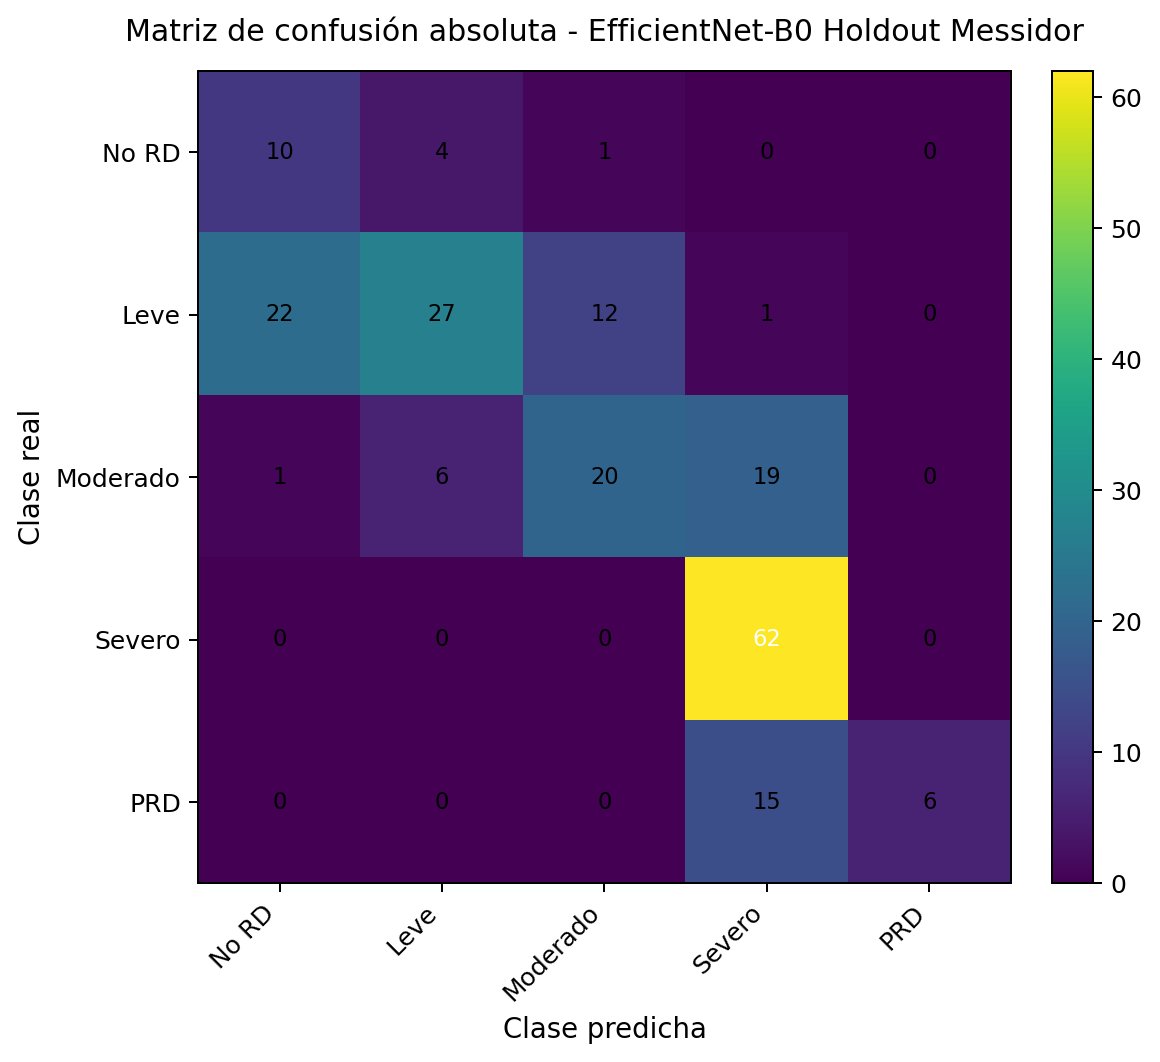

Figura guardada en: resultados_matrices_tesis\EfficientNet-B0 Holdout Messidor_matriz_absoluta.png


In [85]:
plot_confusion_matrix(
    matrix=cm_abs,
    class_names=class_names,
    title=f"Matriz de confusión absoluta - {model_name}",
    filename=f"{model_name}_matriz_absoluta.png",
    fmt="d"
)

# 7. Graficar matriz normalizada por fila

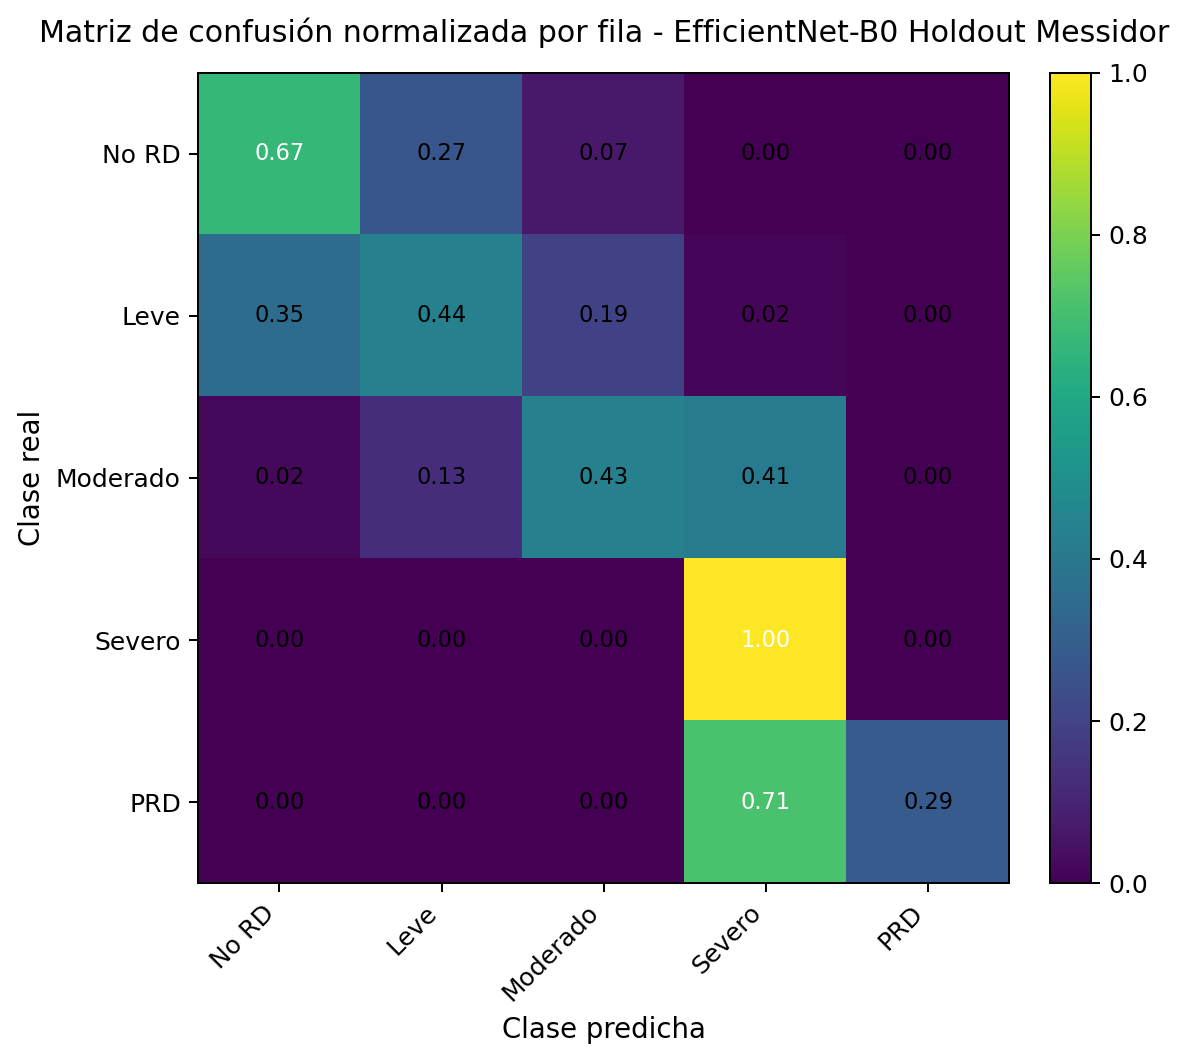

Figura guardada en: resultados_matrices_tesis\EfficientNet-B0 Holdout Messidor_matriz_normalizada_por_fila.png


In [86]:
plot_confusion_matrix(
    matrix=cm_norm,
    class_names=class_names,
    title=f"Matriz de confusión normalizada por fila - {model_name}",
    filename=f"{model_name}_matriz_normalizada_por_fila.png",
    fmt=".2f",
    vmin=0,
    vmax=1
)

# 8. Gráfico de recall por clase

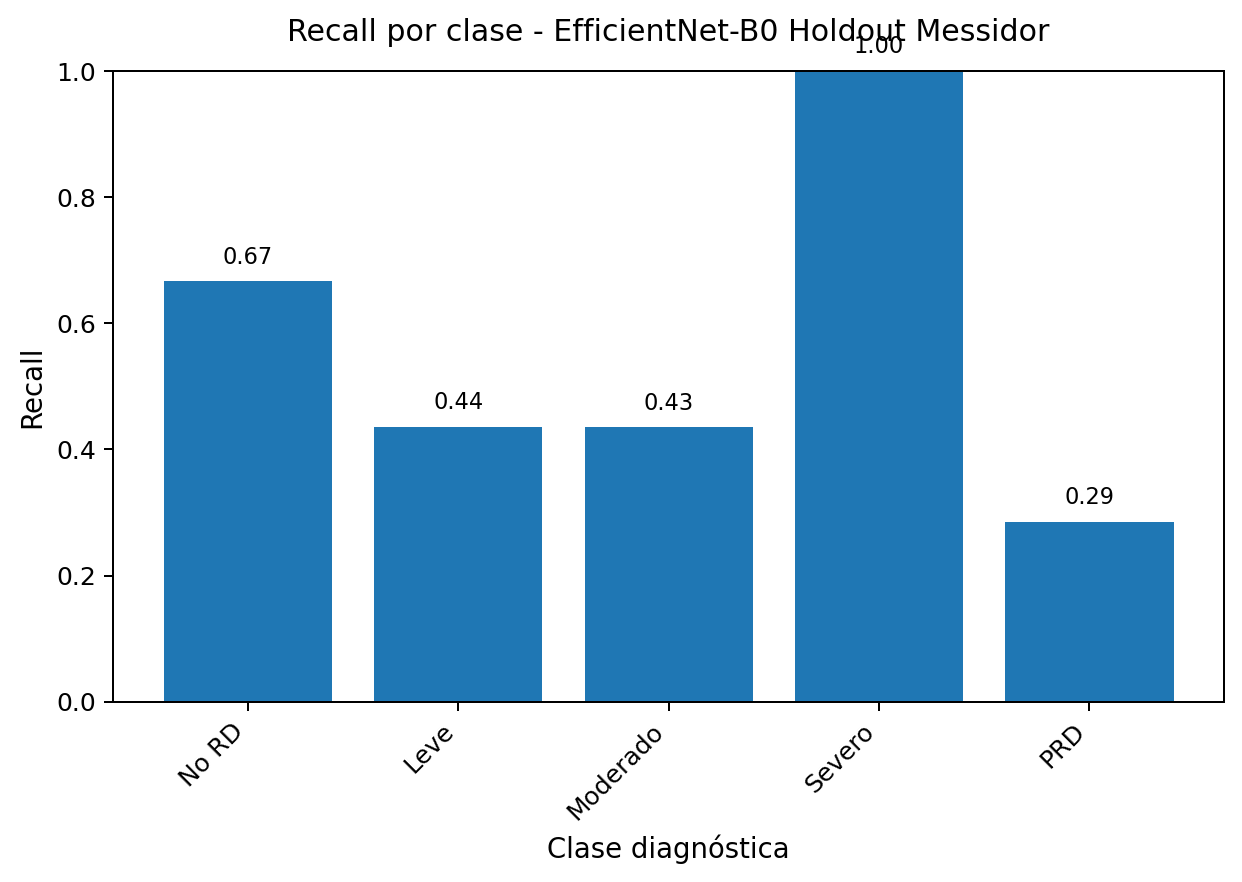

Figura guardada en: resultados_matrices_tesis\EfficientNet-B0 Holdout Messidor_recall_por_clase.png


In [87]:
fig, ax = plt.subplots(figsize=(7, 5), dpi=180)

x = np.arange(len(class_names))
ax.bar(x, recall_por_clase)

ax.set_title(f"Recall por clase - {model_name}", fontsize=12, pad=12)
ax.set_xlabel("Clase diagnóstica", fontsize=11)
ax.set_ylabel("Recall", fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_ylim(0, 1)

# Agregar etiquetas encima de las barras
for i, value in enumerate(recall_por_clase):
    ax.text(
        i,
        value + 0.02,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()

recall_plot_path = OUTDIR / f"{model_name}_recall_por_clase.png"
plt.savefig(recall_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figura guardada en: {recall_plot_path}")